# Kepler-51 planetary system in the light of the PhotoRing effect
## Ruling out the PhotoEccentric Effect

This notebook systematically evaluates whether the stellar-density anomalies detected via asterodensity profiling of Kepler-51 b and d can be explained by the PhotoEccentric effect (Kipping 2014, Eq. 33-34), rather than by the PhotoRing effect (Zuluaga et al. 2015).

Here we reproduce the two diagnostic figures for the PhotoEccentric effect presented in the paper.

- `figures/pe_psi_distribution.png`
- `figures/pe_emin_diagnostic.png`

## Theoretical Background

In the framework of asterodensity profiling (AP), when a planetary transit is fitted assuming a circular orbit, the transit-inferred stellar density ($\rho_{\star,\rm obs}$) can differ from the true stellar density ($\rho_{\star,\rm true}$) if any model assumption is violated. The **PhotoEccentric (PE) effect** (Kipping 2014) is the case where the violation is an unmodelled eccentric orbit.

The fundamental relationship of the PE effect is given by (Kipping 2014, Eq. 33–34):

$$ \frac{\rho_{\star,\rm obs}}{\rho_{\star,\rm true}} = \Psi(e, \omega) \equiv \frac{(1 + e\sin\omega)^3}{(1-e^2)^{3/2}} $$

where $e$ is the orbital eccentricity and $\omega$ is the argument of periastron.

For multi-planetary systems, we can define the Multi-body AP (MAP) observable $\Theta_{bd}$ to compare the inferred densities between two planets (e.g., b and d) and eliminate the dependence on the true stellar density (Kipping et al. 2012):

$$ \Theta_{bd} \equiv \left(\frac{\rho_{\star,\rm obs}(b)}{\rho_{\star,\rm obs}(d)}\right)^{2/3} = \left(\frac{\Psi_b}{\Psi_d}\right)^{2/3} $$

In this notebook, we quantitatively test if the orbital eccentricities of Kepler-51b and d (measured via TTVs by Masuda et al. 2024) can produce a PE effect large enough to explain the observed density anomalies, or if we need to invoke another effect (e.g., the PhotoRing effect).

## Preparing the environment

In [1]:
%matplotlib inline
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline" / "photoring").is_dir() and (c / "pipeline" / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO / "pipeline"), str(_REPO)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)

repo root: /Users/jzuluaga/dev/PRisma


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot


# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

CASE = "kepler_51"
# This notebook does not live in pipeline/, so point CasePaths at it explicitly.
paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
IMG = pathlib.Path(_REPO / "papers" / "kepler51" / "figures")
IMG.mkdir(parents=True, exist_ok=True)
print("writing figures to:", IMG)

writing figures to: /Users/jzuluaga/dev/PRisma/papers/kepler51/figures


## 1. Constants and Physical Functions

We define the PhotoEccentric functions derived by Kipping (2014) to connect the unmodelled eccentricity to the apparent anomaly in the stellar density $\Psi = \rho_{\star,\rm obs} / \rho_{\star,\rm true}$.

In [3]:
# Color palette
C_B = "#2166AC"       # Kepler-51b
C_D = "#D95F02"       # Kepler-51d
C_TRUE = "#C51B7D"    # rho_true
C_PE = "#4DAF4A"      # PE effect
C_MAP = "#984EA3"     # MAP

GCONST = 6.67428e-11   # m^3 kg^-1 s^-2
KG_M3_TO_GCC = 1e-3    # kg/m³ → g/cm³

def psi_pe(e, omega):
    """PhotoEccentric effect: ρ_obs/ρ_true = Ψ (Kipping 2014, Eq. 33-34)."""
    return (1 + e * np.sin(omega))**3 / (1 - e**2)**1.5

def emin_from_density_ratio(ratio):
    """Minimum eccentricity compatible with a density ratio (Kipping 2014, Eq. 39)."""
    ratio = np.asarray(ratio, dtype=float)
    r23 = ratio**(2.0/3.0)
    
    # Case 1: ratio >= 1 (Ψ >= 1 → ω near π/2)
    e1 = (r23 - 1) / (r23 + 1)
    
    # Case 2: ratio < 1 (Ψ < 1 → ω near 3π/2)
    r43 = ratio**(4.0/3.0)
    numerator = (1 - r23) * (1 - r23 + r43)
    denominator = (1 + r23)**2
    e2 = np.sqrt(np.clip(numerator / denominator, 0, None))
    
    emin = np.where(ratio >= 1.0, e1, e2)
    return emin

def pr_scale(rho_obs, rho_true):
    """PhotoRing logarithmic scale (Zuluaga 2015, Eq. 1 of paper)."""
    return 10.0 * np.log10(rho_obs / rho_true)

# Masuda 2024 solutions
MASUDA_OUTSIDE = {
    "b": {"e": 0.0162, "e_sd": 0.0038,
          "ecosw": -0.0156, "ecosw_sd": 0.0038,
          "esinw": -0.0012, "esinw_sd": 0.0044},
    "d": {"e": 0.0076, "e_sd": 0.0058,
          "ecosw": -0.0046, "ecosw_sd": 0.0059,
          "esinw": 0.0022, "esinw_sd": 0.0066},
}

MASUDA_INSIDE = {
    "b": {"e": 0.0162, "e_sd": 0.0038,
          "ecosw": -0.0156, "ecosw_sd": 0.0038,
          "esinw": -0.0012, "esinw_sd": 0.0044},
    "d": {"e": 0.020, "e_sd": 0.015,
          "ecosw": -0.011, "ecosw_sd": 0.015,
          "esinw": -0.0068, "esinw_sd": 0.0148},
}

def sample_eccentricity(planet, solution="outside", N=100_000, rng=None):
    """Generate (e, ω) samples from Masuda 2024 posteriors."""
    if rng is None:
        rng = np.random.default_rng(42)
    
    data = MASUDA_OUTSIDE[planet] if solution == "outside" else MASUDA_INSIDE[planet]
    
    ecosw = rng.normal(data["ecosw"], data["ecosw_sd"], N)
    esinw = rng.normal(data["esinw"], data["esinw_sd"], N)
    
    e = np.sqrt(ecosw**2 + esinw**2)
    omega = np.arctan2(esinw, ecosw)
    
    # Reject unphysical samples
    mask = (e >= 0) & (e < 1)
    return e[mask], omega[mask]

## 2. Load TTV observables and the independent stellar density

In [4]:
def load_observables(path):
    cols = ["p", "delta", "aR", "rho_obs", "P", "b", "i_orb", "T14", "T23"]
    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None, names=cols)
    return df

# Adopted reference for the true stellar density: the isochrone-based value of
# Masuda et al. (2024), 2.08 +/- 0.08 g/cm^3, modelled as a normal distribution.
# (Previously we used the Berger et al. 2023 posterior samples, 1.896 -0.246/+0.218.)
RHO_TRUE_MU, RHO_TRUE_SD = 2.08, 0.08   # g/cm^3
N_RHO_TRUE = 200_000

def load_rho_true():
    """Sample the true stellar density (Masuda 2024) and return it in kg/m³."""
    rng = np.random.default_rng(2026)
    samples_gcc = rng.normal(RHO_TRUE_MU, RHO_TRUE_SD, N_RHO_TRUE)
    return samples_gcc / KG_M3_TO_GCC

obs_b = load_observables(paths.observables_file("b"))
obs_d = load_observables(paths.observables_file("d"))
rho_true = load_rho_true()

rho_true_gcc = rho_true * KG_M3_TO_GCC
rho_obs_b_gcc = obs_b["rho_obs"].values * KG_M3_TO_GCC
rho_obs_d_gcc = obs_d["rho_obs"].values * KG_M3_TO_GCC

rho_true_median = np.median(rho_true_gcc)
ratio_b = np.median(rho_obs_b_gcc) / rho_true_median
ratio_d = np.median(rho_obs_d_gcc) / rho_true_median

print(f"ρ★,true (Masuda 2024 median): {rho_true_median:.3f} g/cm³")
print(f"ρ★,obs(b) median: {np.median(rho_obs_b_gcc):.3f} g/cm³")
print(f"ρ★,obs(d) median: {np.median(rho_obs_d_gcc):.3f} g/cm³")
print(f"ρ★,obs(b)/ρ★,true = {ratio_b:.4f}")
print(f"ρ★,obs(d)/ρ★,true = {ratio_d:.4f}")

ρ★,true (Masuda 2024 median): 2.080 g/cm³
ρ★,obs(b) median: 2.462 g/cm³
ρ★,obs(d) median: 2.171 g/cm³
ρ★,obs(b)/ρ★,true = 1.1838
ρ★,obs(d)/ρ★,true = 1.0436


## 3. PE $\Psi(e,\omega)$ for Known Eccentricities

Here we sample the eccentricities from Masuda 2024 and evaluate the induced PhotoEccentric effect $\Psi$. We compare this prediction directly against the density anomaly $\Psi$ observed from our photometric analysis.

**Manuscript figure:** `pe_psi_distribution.png`.

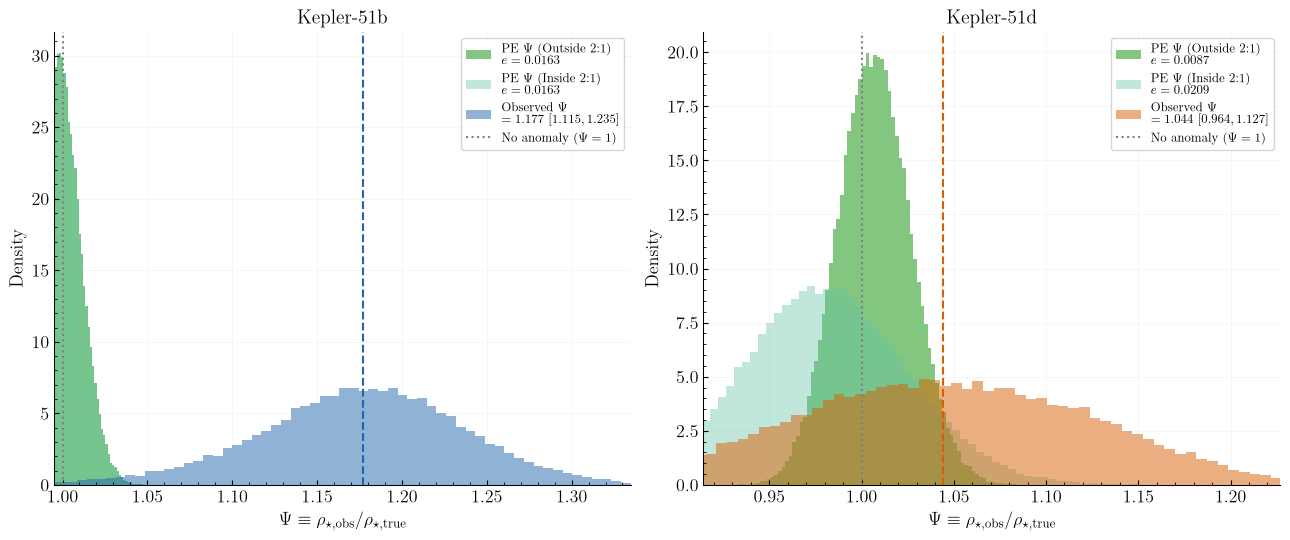

In [5]:
# Sample eccentricities for both solutions
results = {}
for solution in ["outside", "inside"]:
    for planet in ["b", "d"]:
        e_samp, omega_samp = sample_eccentricity(planet, solution)
        psi_samp = psi_pe(e_samp, omega_samp)
        
        key = f"{planet}_{solution}"
        results[key] = {
            "e": e_samp, "omega": omega_samp, "psi": psi_samp,
            "psi_median": np.median(psi_samp),
            "psi_q16": np.percentile(psi_samp, 16),
            "psi_q84": np.percentile(psi_samp, 84),
        }

# --- FIGURE: Ψ distribution vs observed anomalies ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax_idx, (planet, color, ratio_obs) in enumerate([
    ("b", C_B, ratio_b), ("d", C_D, ratio_d)
]):
    ax = axes[ax_idx]
    
    # PE Ψ distribution
    psi_out = results[f"{planet}_outside"]["psi"]
    ax.hist(psi_out, bins=100, density=True, alpha=0.7, color=C_PE,
            label=fr"PE $\Psi$ (Outside 2:1)" + "\n" + fr"$e = {np.median(results[f'{planet}_outside']['e']):.4f}$")
    
    if f"{planet}_inside" in results:
        psi_in = results[f"{planet}_inside"]["psi"]
        ax.hist(psi_in, bins=100, density=True, alpha=0.4, color="#66C2A5",
                label=fr"PE $\Psi$ (Inside 2:1)" + "\n" + fr"$e = {np.median(results[f'{planet}_inside']['e']):.4f}$")
    
    # Observed anomaly (vertical band)
    N_boot = 50_000
    rng = np.random.default_rng(42)
    rho_obs_samp = rho_obs_b_gcc if planet == "b" else rho_obs_d_gcc
    idx_obs = rng.integers(0, len(rho_obs_samp), N_boot)
    idx_true = rng.integers(0, len(rho_true_gcc), N_boot)
    ratio_dist = rho_obs_samp[idx_obs] / rho_true_gcc[idx_true]
    
    ratio_med = np.median(ratio_dist)
    ratio_lo = np.percentile(ratio_dist, 16)
    ratio_hi = np.percentile(ratio_dist, 84)
    
    ax.hist(ratio_dist, bins=100, density=True, alpha=0.5, color=color,
            label=fr"Observed $\Psi$" + "\n" + fr"$= {ratio_med:.3f}$ $[{ratio_lo:.3f}, {ratio_hi:.3f}]$")
    ax.axvline(ratio_med, color=color, ls="--", lw=1.5)
    
    # Reference line
    ax.axvline(1.0, color="gray", ls=":", lw=1.5, label=r"No anomaly ($\Psi = 1$)")
    
    ax.set_xlabel(r"$\Psi \equiv \rho_{\star,\mathrm{obs}}/\rho_{\star,\mathrm{true}}$", fontsize=13)
    ax.set_ylabel("Density", fontsize=13)
    ax.set_title(f"Kepler-51{planet}", fontsize=14, fontweight="bold")
    ax.legend(fontsize=9, loc="upper right")
    
    # Set x-limits to show both PE and anomaly
    xlim_lo = min(0.995, ratio_lo - 0.05)
    xlim_hi = max(1.005, ratio_hi + 0.1)
    ax.set_xlim(xlim_lo, xlim_hi)

plt.tight_layout()
fig.savefig(IMG / "pe_psi_distribution.png")
plt.show()

## 4. Diagnostic Diagram $e_{min}$ vs $\Psi$

In this final section we construct the analytic minimum eccentricity $e_{min}$ curve from Kipping (2014) as a function of the density ratio $\Psi$, and we place Kepler-51 b and d on it, so that the required eccentricities can be compared against the dynamical constraints. Note that the offsets are modest: with $\rho_{\star,\rm true}=2.08\pm0.08$ (Masuda 2024), planet b sits $2.9\sigma$ from $\Psi=1$ and planet d only $0.6\sigma$.

**Manuscript figure:** `pe_emin_diagnostic.png`.

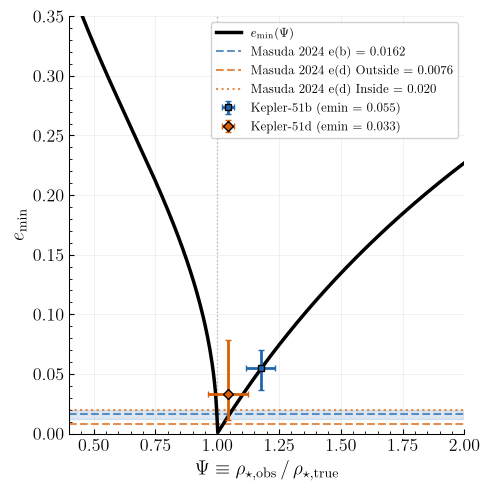

In [6]:
# Compute emin for observed ratios
# Uncertainties via bootstrap
rng = np.random.default_rng(42)
N_boot = 50_000

idx_b = rng.integers(0, len(rho_obs_b_gcc), N_boot)
idx_true1 = rng.integers(0, len(rho_true_gcc), N_boot)
ratio_b_samp = rho_obs_b_gcc[idx_b] / rho_true_gcc[idx_true1]

idx_d = rng.integers(0, len(rho_obs_d_gcc), N_boot)
idx_true2 = rng.integers(0, len(rho_true_gcc), N_boot)
ratio_d_samp = rho_obs_d_gcc[idx_d] / rho_true_gcc[idx_true2]

emin_b_samp = emin_from_density_ratio(ratio_b_samp)
emin_d_samp = emin_from_density_ratio(ratio_d_samp)

ratio_b_med = np.median(ratio_b_samp)
ratio_b_lo, ratio_b_hi = np.percentile(ratio_b_samp, [16, 84])
emin_b_med = np.median(emin_b_samp)
emin_b_lo, emin_b_hi = np.percentile(emin_b_samp, [16, 84])

ratio_d_med = np.median(ratio_d_samp)
ratio_d_lo, ratio_d_hi = np.percentile(ratio_d_samp, [16, 84])
emin_d_med = np.median(emin_d_samp)
emin_d_lo, emin_d_hi = np.percentile(emin_d_samp, [16, 84])

# --- FIGURE: Diagnostic diagram ---
fig, ax = plt.subplots(figsize=(5, 5))

# Analytic curve
ratios = np.logspace(-0.5, 0.5, 500)
emin_curve = emin_from_density_ratio(ratios)
ax.plot(ratios, emin_curve, "k-", lw=2.5, zorder=5,
        label=r"$e_{\min}(\Psi)$")

# Kepler-51b
fac = 0.4
ax.errorbar(ratio_b_med, emin_b_med,
            xerr=[[ratio_b_med - ratio_b_lo], [ratio_b_hi - ratio_b_med]],
            yerr=[[emin_b_med - emin_b_lo], [emin_b_hi - emin_b_med]],
            fmt="s", ms=12*fac, color=C_B, ecolor=C_B, capsize=5*fac,
            elinewidth=2, markeredgecolor="black", markeredgewidth=1,
            zorder=10, label=f"Kepler-51b (emin = {emin_b_med:.3f})")

# Kepler-51d
ax.errorbar(ratio_d_med, emin_d_med,
            xerr=[[ratio_d_med - ratio_d_lo], [ratio_d_hi - ratio_d_med]],
            yerr=[[emin_d_med - emin_d_lo], [emin_d_hi - emin_d_med]],
            fmt="D", ms=12*fac, color=C_D, ecolor=C_D, capsize=5*fac,
            elinewidth=2, markeredgecolor="black", markeredgewidth=1,
            zorder=10, label=f"Kepler-51d (emin = {emin_d_med:.3f})")

# Masuda eccentricities (horizontal bands)
e_masuda_b = 0.0162
e_masuda_b_err = 0.0038
ax.axhspan(e_masuda_b - e_masuda_b_err, e_masuda_b + e_masuda_b_err,
           alpha=0.15, color=C_B, zorder=1)
ax.axhline(e_masuda_b, color=C_B, ls="--", lw=1.5, alpha=0.7,
           label=f"Masuda 2024 e(b) = {e_masuda_b:.4f}")

e_masuda_d_out = 0.0076
e_masuda_d_in = 0.020
ax.axhline(e_masuda_d_out, color=C_D, ls="--", lw=1.5, alpha=0.7,
           label=f"Masuda 2024 e(d) Outside = {e_masuda_d_out:.4f}")
ax.axhline(e_masuda_d_in, color=C_D, ls=":", lw=1.5, alpha=0.7,
           label=f"Masuda 2024 e(d) Inside = {e_masuda_d_in:.3f}")

# Reference line
ax.axvline(1.0, color="gray", ls=":", lw=1, alpha=0.5)

ax.set_xlabel(r"$\Psi\equiv\rho_{\star,\mathrm{obs}}\,/\,\rho_{\star,\mathrm{true}}$", fontsize=14)
ax.set_ylabel(r"$e_{\min}$", fontsize=14)
ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
ax.set_xlim(0.4, 2.0)
ax.set_ylim(0, 0.35)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(IMG / "pe_emin_diagnostic.png")
plt.show()

## 5. Combined PE Anomalies Diagram

Finally, we construct a 3-panel figure showing the PE $\Psi$ distribution for planets b and d, and their inter-planet density ratio MAP, compared with the observations.

**Manuscript figure:** `pe_anomalies.png`.

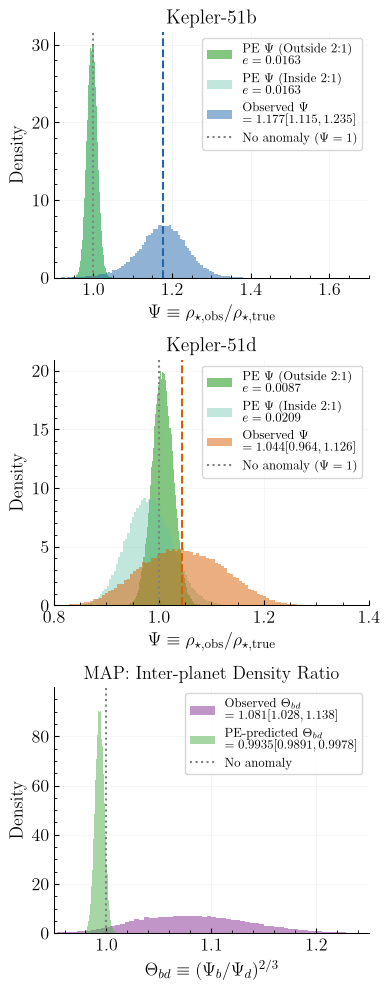

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(4, 10))

# ---------------------------------------------------------
# Panel 1: Kepler-51b (from exp1)
# ---------------------------------------------------------
ax = axes[0]
planet = "b"
color = C_B
ratio_obs = ratio_b
psi_out = results[f"{planet}_outside"]["psi"]

ax.hist(psi_out, bins=100, density=True, alpha=0.7, color=C_PE,
        label=fr"PE $\Psi$ (Outside 2:1)" + "\n" + fr"$e = {np.median(results[f'{planet}_outside']['e']):.4f}$")
if f"{planet}_inside" in results:
    psi_in = results[f"{planet}_inside"]["psi"]
    ax.hist(psi_in, bins=100, density=True, alpha=0.4, color="#66C2A5",
            label=fr"PE $\Psi$ (Inside 2:1)" + "\n" + fr"$e = {np.median(results[f'{planet}_inside']['e']):.4f}$")

N_boot = 50_000
rng = np.random.default_rng(42)
idx_obs = rng.integers(0, len(rho_obs_b_gcc), N_boot)
idx_true = rng.integers(0, len(rho_true_gcc), N_boot)
ratio_dist = rho_obs_b_gcc[idx_obs] / rho_true_gcc[idx_true]
ratio_med = np.median(ratio_dist)
ratio_lo = np.percentile(ratio_dist, 16)
ratio_hi = np.percentile(ratio_dist, 84)

ax.hist(ratio_dist, bins=100, density=True, alpha=0.5, color=color,
        label=fr"Observed $\Psi$" + "\n" + fr"$= {ratio_med:.3f} [{ratio_lo:.3f}, {ratio_hi:.3f}]$")
ax.axvline(ratio_med, color=color, ls="--", lw=1.5)
ax.axvline(1.0, color="gray", ls=":", lw=1.5, label=r"No anomaly ($\Psi = 1$)")

ax.set_xlabel(r"$\Psi \equiv \rho_{\star,\mathrm{obs}}/\rho_{\star,\mathrm{true}}$", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title(f"Kepler-51b", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(0.9,1.7)

# ---------------------------------------------------------
# Panel 2: Kepler-51d (from exp1)
# ---------------------------------------------------------
ax = axes[1]
planet = "d"
color = C_D
ratio_obs = ratio_d
psi_out = results[f"{planet}_outside"]["psi"]

ax.hist(psi_out, bins=100, density=True, alpha=0.7, color=C_PE,
        label=fr"PE $\Psi$ (Outside 2:1)" + "\n" + fr"$e = {np.median(results[f'{planet}_outside']['e']):.4f}$")
if f"{planet}_inside" in results:
    psi_in = results[f"{planet}_inside"]["psi"]
    ax.hist(psi_in, bins=100, density=True, alpha=0.4, color="#66C2A5",
            label=fr"PE $\Psi$ (Inside 2:1)" + "\n" + fr"$e = {np.median(results[f'{planet}_inside']['e']):.4f}$")
            
idx_obs = rng.integers(0, len(rho_obs_d_gcc), N_boot)
idx_true = rng.integers(0, len(rho_true_gcc), N_boot)
ratio_dist = rho_obs_d_gcc[idx_obs] / rho_true_gcc[idx_true]
ratio_med = np.median(ratio_dist)
ratio_lo = np.percentile(ratio_dist, 16)
ratio_hi = np.percentile(ratio_dist, 84)

ax.hist(ratio_dist, bins=100, density=True, alpha=0.5, color=color,
        label=fr"Observed $\Psi$" + "\n" + fr"$= {ratio_med:.3f} [{ratio_lo:.3f}, {ratio_hi:.3f}]$")
ax.axvline(ratio_med, color=color, ls="--", lw=1.5)
ax.axvline(1.0, color="gray", ls=":", lw=1.5, label=r"No anomaly ($\Psi = 1$)")

ax.set_xlabel(r"$\Psi \equiv \rho_{\star,\mathrm{obs}}/\rho_{\star,\mathrm{true}}$", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title(f"Kepler-51d", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(0.8, 1.4)

# ---------------------------------------------------------
# Panel 3: MAP (from exp2)
# ---------------------------------------------------------
ax = axes[2]
N_map = 50_000
idx_b = rng.integers(0, len(rho_obs_b_gcc), N_map)
idx_d = rng.integers(0, len(rho_obs_d_gcc), N_map)
map_ratio = (rho_obs_b_gcc[idx_b] / rho_obs_d_gcc[idx_d])**(2.0/3.0)
map_med = np.median(map_ratio)
map_lo = np.percentile(map_ratio, 16)
map_hi = np.percentile(map_ratio, 84)

e_b, w_b = sample_eccentricity("b", "outside", N_map)
e_d, w_d = sample_eccentricity("d", "outside", N_map)
psi_b = psi_pe(e_b[:N_map], w_b[:N_map])
psi_d = psi_pe(e_d[:N_map], w_d[:N_map])
pe_map_ratio = (psi_b / psi_d)**(2.0/3.0)
pe_map_med = np.median(pe_map_ratio)
pe_map_lo = np.percentile(pe_map_ratio, 16)
pe_map_hi = np.percentile(pe_map_ratio, 84)

ax.hist(map_ratio, bins=100, density=True, alpha=0.6, color=C_MAP,
         label=r"Observed $\Theta_{bd}$" + "\n" + fr"$= {map_med:.3f} [{map_lo:.3f}, {map_hi:.3f}]$")
ax.hist(pe_map_ratio, bins=100, density=True, alpha=0.5, color=C_PE,
         label=r"PE-predicted $\Theta_{bd}$" + "\n" + fr"$= {pe_map_med:.4f} [{pe_map_lo:.4f}, {pe_map_hi:.4f}]$")
ax.axvline(1.0, color="gray", ls=":", lw=1.5, label="No anomaly")
ax.set_xlabel(r"$\Theta_{bd} \equiv (\Psi_b/\Psi_d)^{2/3}$", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("MAP: Inter-planet Density Ratio", fontsize=13, fontweight="bold")
ax.set_xlim(0.95, 1.25)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
fig.savefig(IMG / "pe_anomalies.png")
plt.show()

In [8]:
def prob_pe_explains_anomaly(planet_name, psi_pe, rho_obs):
    # Sample observed psi
    rng = np.random.default_rng(42)
    idx_obs = rng.integers(0, len(rho_obs), len(psi_pe))
    idx_true = rng.integers(0, len(rho_true_gcc), len(psi_pe))
    psi_obs = rho_obs[idx_obs] / rho_true_gcc[idx_true]
    
    prob = np.mean(psi_pe >= psi_obs) * 100
    print(f"Probabilidad de que el Efecto Fotoexcéntrico (PE) explique la densidad de Kepler-51{planet_name}: {prob:.1f}%")

print("--- PE Explanation Probabilities ---")
prob_pe_explains_anomaly('b', results['b_outside']['psi'], rho_obs_b_gcc)
prob_pe_explains_anomaly('d', results['d_outside']['psi'], rho_obs_d_gcc)


--- PE Explanation Probabilities ---
Probabilidad de que el Efecto Fotoexcéntrico (PE) explique la densidad de Kepler-51b: 0.8%
Probabilidad de que el Efecto Fotoexcéntrico (PE) explique la densidad de Kepler-51d: 32.9%
